# **SEMINAR 3**

**In this last seminar, you will be introduced to Federated Learning (FL), a popular
technique to train Machine Learning (ML) models collaboratively. Once again, you
will work on the pose estimation problem viewed in Seminar 2, but this time data will
be distributed among multiple clients. The dataset that you are going to use in this
seminar (dataset Seminar5.zip) contains Wi-Fi signals (in the form of Channel State
Information matrix) measured when a person was doing a given pose (e.g., walk, run,
sit down, etc.).1
Instead of having a single training dataset, you will have datasets
from K = 10 clients, and your job will be to train a global model with the individual
contributions of each client.**

**PART** **1**

The dataset is known by you, so you are already able to load and process it as needed.
For that reason, you will start focusing on the ML model that you will train collaboratively
through FL. In this regard, you are free to choose the model architecture that you believe
(you can also work with the linear regressor that you implemented in Seminar 2). Remember
that we are dealing with a classification problem, which may have implications in your model
architecture (e.g., selected loss function, type of activations).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import os
import random
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [3]:
num_clients = 10

DATA_PATH = "/content/drive/Shared drives//ML4N/seminar 5"
CLIENT_PATH = "/content/drive/Shared drives//ML4N/seminar 5/client_dataset"

client_data = {} #dict to store all the data of the clients

for i in range(1, num_clients +1): #we iterate the 10 clients
  #load the features and labels of each client
  X_path = os.path.join(CLIENT_PATH, f"client_{i}_features.csv")
  y_path = os.path.join(CLIENT_PATH, f"client_{i}_labels.csv")

  X = pd.read_csv(X_path, header=None)
  y = pd.read_csv(y_path, header=None)
  y=pd.Series(y.values.ravel()) #convert the labels into a 1D vector (since the original one is one row)

  client_data[i] = {"X": X, "y": y} #store teh feature and labels of each client into the dicctionary

#the same but for the test set
X_test = pd.read_csv(os.path.join(DATA_PATH, "test_features.csv"), header=None)
y_test = pd.read_csv(os.path.join(DATA_PATH, "test_labels.csv"), header=None)
y_test = pd.Series(y_test.values.ravel())

In [4]:
#info of the client and test data
for k in range(1, num_clients + 1):
    X = client_data[k]["X"]
    y = client_data[k]["y"]

    print(f"Client {k}")
    print("Features shape:", X.shape)
    print("Labels shape:", y.shape)
    print("Classes:", sorted(y.unique()))
    print()

print("Test features shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Client 1
Features shape: (314, 270)
Labels shape: (314,)
Classes: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(11)]

Client 2
Features shape: (113, 270)
Labels shape: (113,)
Classes: [np.int64(2), np.int64(7)]

Client 3
Features shape: (365, 270)
Labels shape: (365,)
Classes: [np.int64(2), np.int64(4), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

Client 4
Features shape: (207, 270)
Labels shape: (207,)
Classes: [np.int64(1), np.int64(6), np.int64(9)]

Client 5
Features shape: (209, 270)
Labels shape: (209,)
Classes: [np.int64(3), np.int64(6), np.int64(8)]

Client 6
Features shape: (202, 270)
Labels shape: (202,)
Classes: [np.int64(5), np.int64(6), np.int64(12)]

Client 7
Features shape: (448, 270)
Labels shape: (448,)
Classes: [np.int64(1), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Client 8
Features shape: (142, 270)
Labels shape: (142,)
Classes: [np.int64(5), np.int64(6), np.int64

In [5]:
for i in range(1, num_clients +1):
  X = client_data[i]["X"]
  y = client_data[i]["y"]
  print(f"Client {i}")
  print(f"X nulls: {X.isnull().sum().sum()}")
  print(f"y nulls: {y.isnull().sum()}")

print(f"Nulls for test X: {X_test.isnull().sum().sum()}")
print(f"Nulls for test y: {y_test.isnull().sum().sum()}")

Client 1
X nulls: 0
y nulls: 0
Client 2
X nulls: 0
y nulls: 0
Client 3
X nulls: 0
y nulls: 0
Client 4
X nulls: 0
y nulls: 0
Client 5
X nulls: 0
y nulls: 0
Client 6
X nulls: 0
y nulls: 0
Client 7
X nulls: 0
y nulls: 0
Client 8
X nulls: 0
y nulls: 0
Client 9
X nulls: 0
y nulls: 0
Client 10
X nulls: 0
y nulls: 0
Nulls for test X: 0
Nulls for test y: 0


Since there are no nulls we don't have to drop or compute them.

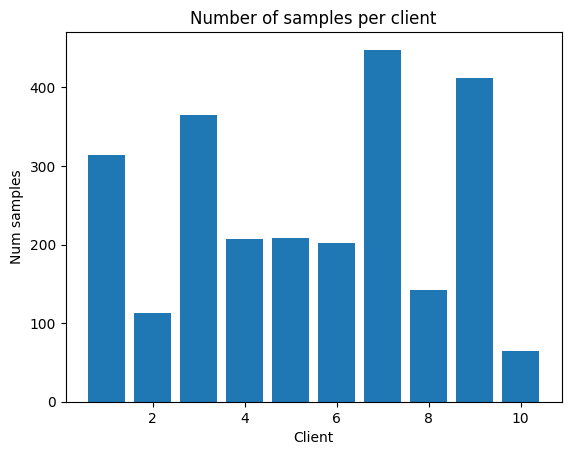

In [6]:
client_sizes = [] #array to store the sizes of each client dataset

for i in range(1, num_clients +1):
  n_samples = len(client_data[i]["y"])
  client_sizes.append(n_samples)

plt.figure()
plt.bar(range(1, num_clients + 1), client_sizes)
plt.xlabel("Client")
plt.ylabel("Num samples")
plt.title("Number of samples per client")
plt.show()

We can see that not all the clients have the same number of samples. The client that have the most samples is the client 7 and the less samples client 10. This is important for FL since not all clients contribute in the same way. The clients with more samples have more weight in the global model aggregation.

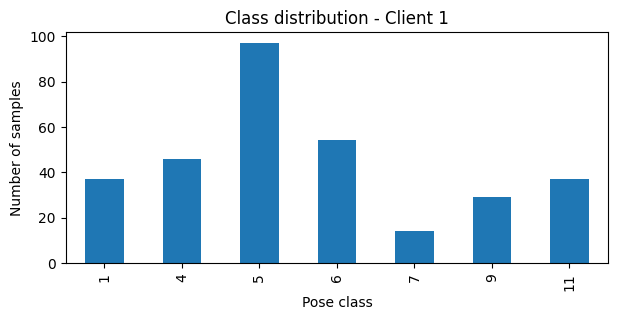

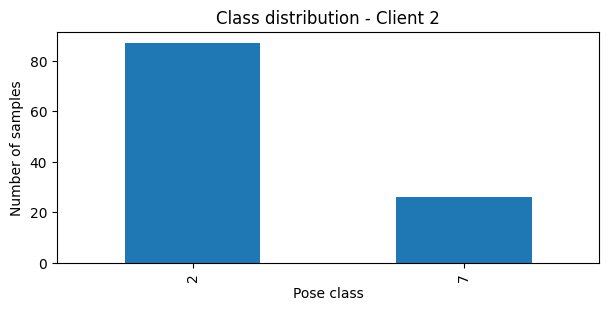

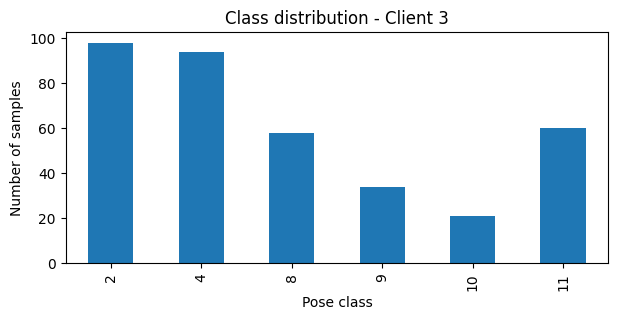

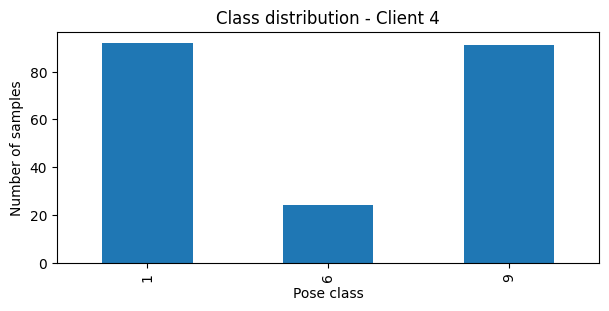

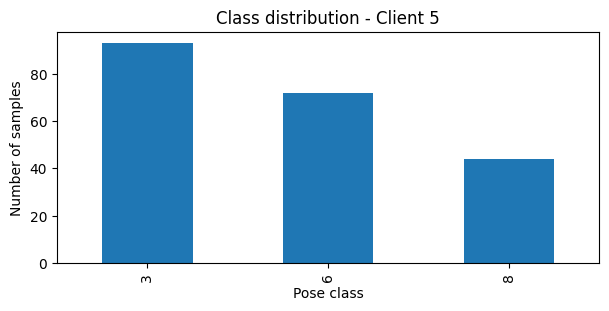

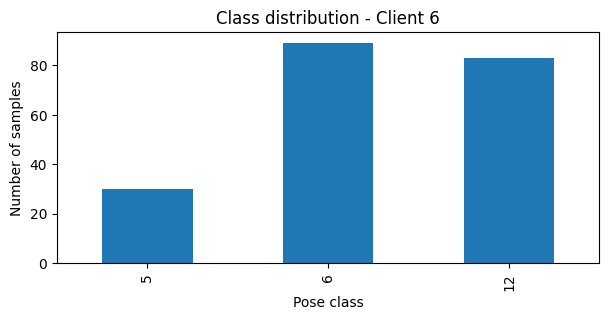

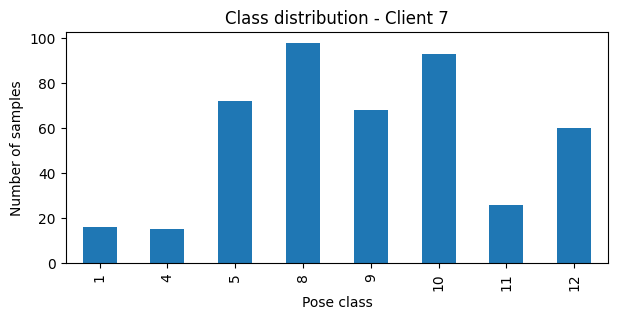

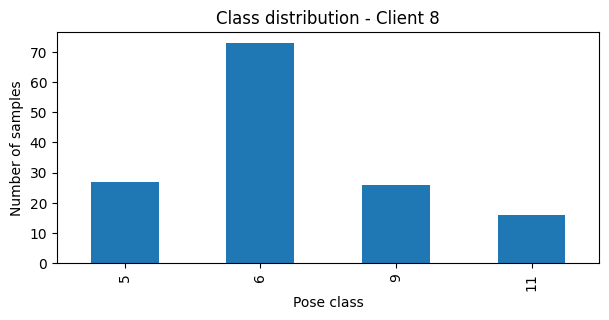

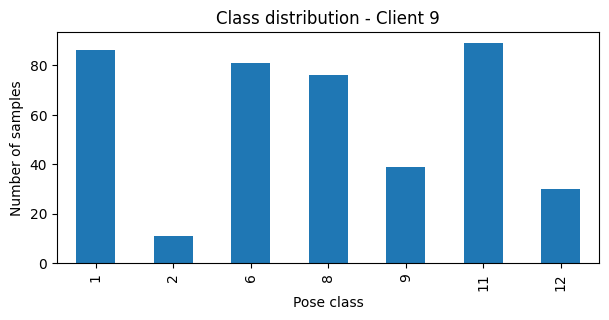

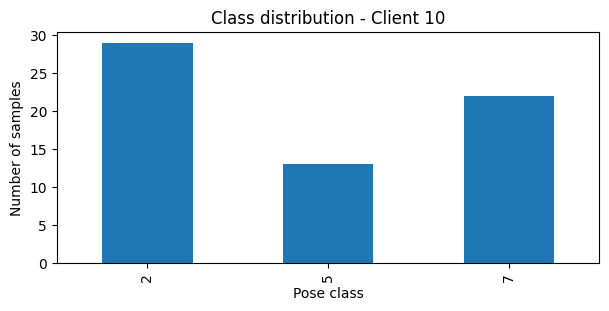

In [7]:
for k in range(1, num_clients + 1):
    y = client_data[k]["y"]

    plt.figure(figsize=(7, 3))
    y.value_counts().sort_index().plot(kind="bar")
    plt.xlabel("Pose class")
    plt.ylabel("Number of samples")
    plt.title(f"Class distribution - Client {k}")
    plt.show()

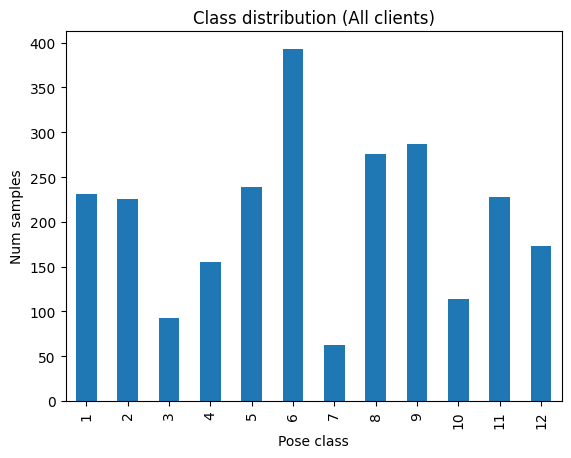

In [8]:
all_y_client = pd.concat(
    [client_data[i]["y"] for i in range(1, num_clients + 1)],
    axis=0
)

plt.figure()
all_y_client.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Pose class")
plt.ylabel("Num samples")
plt.title("Class distribution (All clients)")
plt.show()


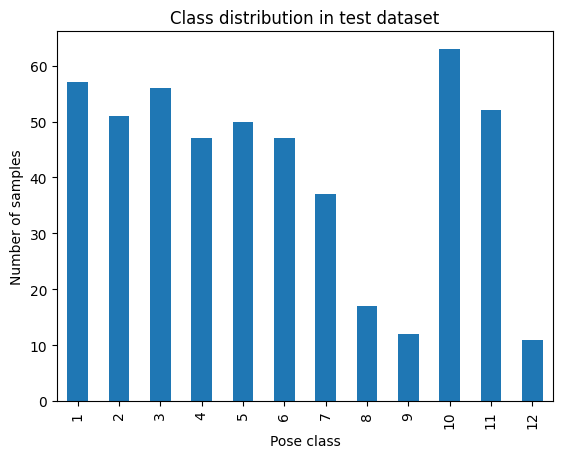

In [9]:
plt.figure()
y_test.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Pose class")
plt.ylabel("Number of samples")
plt.title("Class distribution in test dataset")
plt.show()

Here we can see that the data is not equally distributed since there are clients with more poses than others or with more number of samples. This says to us thet the dataset is non-IID, since clients don't follow the same class distribution.

In [10]:
all_X_client = pd.concat(
    [client_data[i]["X"] for i in range(1, num_clients + 1)],
    axis=0
)

print(all_X_client.describe())

               0            1            2            3            4    \
count  2476.000000  2476.000000  2476.000000  2476.000000  2476.000000   
mean      9.806820    13.699586    15.658368    17.319139    18.517353   
std       4.896313     6.861911     7.576623     8.429222     9.019895   
min       0.000000     0.557630     0.555660     0.787590     0.543180   
25%       6.222050     8.354675     9.723650    10.606000    11.096750   
50%       9.135100    13.060000    15.220000    16.945000    17.848500   
75%      12.918750    18.325750    21.030750    23.256500    25.178000   
max      35.663000    52.369000    56.130000    56.022000    61.121000   

               5            6            7            8            9    ...  \
count  2476.000000  2476.000000  2476.000000  2476.000000  2476.000000  ...   
mean     17.921273    19.077935    19.196164    19.551060    17.815149  ...   
std       9.013501     9.337397     9.467588    10.300339     9.669265  ...   
min       0.55793

Here we can see some information of some of the classes.

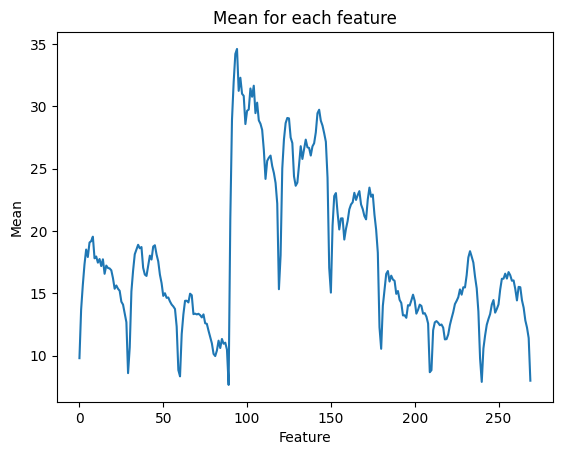

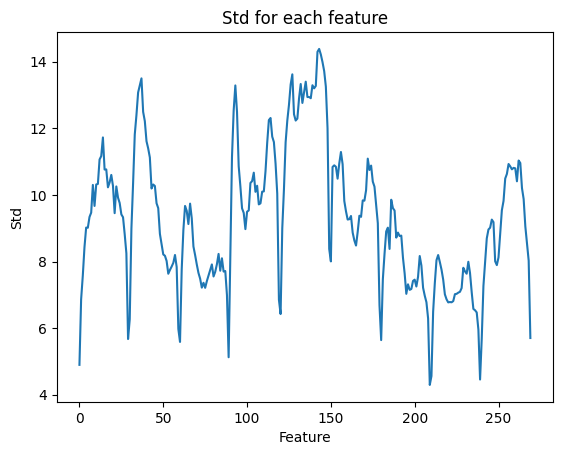

In [11]:
feature_means = all_X_client.mean()
feature_stds = all_X_client.std()

plt.figure()
plt.plot(feature_means.values)
plt.xlabel("Feature")
plt.ylabel("Mean")
plt.title("Mean for each feature")
plt.show()

plt.figure()
plt.plot(feature_stds.values)
plt.xlabel("Feature")
plt.ylabel("Std")
plt.title("Std for each feature")
plt.show()

In this plots we can see some things that gives us information. First of all, there are some features that have 8-12 of mean and others that have 30-35 of mean. In fact, the features 90-150 have more mean than the others.

For the std plot, we can see that some features deviate more than others (they have more dispersion in their values) so have less stability.

Thanks to the previous information, we standarize the data so we can use the model better.

In [12]:
global_mean = all_X_client.mean()
global_std = all_X_client.std()

for i in range(1, num_clients+1):
  client_data[i]["X_scaled"] = (client_data[i]["X"] - global_mean) / global_std

X_test_scaled = (X_test - global_mean) / global_std

We relabel the data so is better for the model.

In [13]:
for i in range(1, num_clients+1):
  client_data[i]["y_processed"] = client_data[i]["y"] -1

y_test_processed = y_test -1

Now we do the model

In [14]:
class PoseClassifier(nn.Module): #we define the classs so then we can define the model with PyTorch
    def __init__(self, input_size=270, num_classes=12):
        super(PoseClassifier, self).__init__()

        self.network = nn.Sequential( #is a network like a layer sequence
            #first layer
            nn.Linear(input_size, 256), #transform the input from 270 into 256 neurons
            nn.LayerNorm(256), #normalize the 256 activations of this layer
            #the normalization is done because we saw that the features have different means and std
            nn.ReLU(), #activation function

            #second layer
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),

            #third layer
            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    #forward function
    def forward(self, x):
        return self.network(x)

For the model we define a multilayer perceptron / feed-forward neural network, that is, a network with lineal layers connected one after another.

The model consists into 4 layers:


1.   First layer: first transforms the input from 270 features into 256 neurons. Every neuron learns froma  combination of the 270 features of the input. Then we normalize the activations since we saw in the preprocessing that the means and std of the features are different. Finnaly we apply the function of activation ReLU, that is: ReLU(x)=max(0,x). This allows the model learn the non lineal releations.
2.   Second layer: this layer reduces from 256 to 128 neurons and then it also normalizes and applies the ReLU.
3.  Third layer: reduces from 128 into 64 neurons but then it doesn't normalize.
4.  Output layer: transforms the 12 neurons into 12 outputs (every output is a pose).

The forward function defines how tha data flows between the model. When we call the model, this automatically calls this function. The flow is that the X passes through all the layers.

The final outputs are not probabilities.

1. Initialize a global ML model, ω(t = 0))

In [15]:
if torch.cuda.is_available(): #we select the device
  device = "cuda"
else:
  device = "cpu"

#we join all the y of all the clients
all_y_train = pd.concat(
  [client_data[k]["y_processed"] for k in range(1, 11)],
  axis=0
)

#count how many samples are for every class
class_counts = all_y_train.value_counts().sort_index()

#compute the weights for each class
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

#convert the weights into a tensor of PyTorch
class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32
).to(device)

print("Class counts:")
print(class_counts)

print("Class weights:")
print(class_weights)

#initialize the global model with w(t=o)
global_model = PoseClassifier(input_size=270, num_classes=12)
global_model = global_model.to(device)

#define the loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(global_model.parameters(), lr=0.001)



Class counts:
0     231
1     225
2      93
3     155
4     239
5     393
6      62
7     276
8     287
9     114
10    228
11    173
Name: count, dtype: int64
Class weights:
0     0.693740
1     0.712240
2     1.723160
3     1.033896
4     0.670519
5     0.407771
6     2.584741
7     0.580630
8     0.558376
9     1.405736
10    0.702868
11    0.926323
Name: count, dtype: float64


As we saw before, the data is imablanced across the classes, so we compute class weights from the global distribution of the training labels (all_y_train). The minority classes have larger weights and the majority ones have lighter weights. This is because if the model fails in a minor class then it penalized more this error in the loss function. The general ides is that the model learns only from the most frequent classes and ignores the classes with less samples.

Then, this weights are passed to the CrossEntropyLoss function. We have chosen this one because we are in a multiclass clasification problem. So the model outputs 12 numbers, one for each class, and the target labels are from 0-11. The CrossEntropyLoss penalizes when the model assigns a number that is not high enough to a class compared with other clases.

In this case, we can see that class 5 (original = class 6) have the most samples so have a smaller weight: 0.407771. On the other hand, class 6 (original = class 7) have the smaller number of samples but its weight is the highest: 2.584741

In [16]:
#convert the data of each client into a PyTorch format
def create_client_dataloaders(client_data, batch_size=32):
  client_loaders = {}

  for i in range(1, 11): #we iterate through all the clients
    X = client_data[i]["X_scaled"].to_numpy() #normalized features
    y = client_data[i]["y_processed"].to_numpy() #processed labels

    #convert into tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    #join all the data
    dataset = TensorDataset(X_tensor, y_tensor)

    #create batches for training
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    client_loaders[i] = loader

  return client_loaders


In [17]:
#create the loaders
batch_size = 32
client_loaders = create_client_dataloaders(client_data, batch_size=batch_size)

2. Select a subset of clients S ⊆ K to participate in the current training iteration.

In [18]:
#select subset of clients
def select_clients(num_clients=10, client_fraction=0.5):
  num_selected = max(1, int(num_clients*client_fraction))
  selected_clients = random.sample(range(1, num_clients+1), num_selected)
  return selected_clients

In [19]:
selected_clients = select_clients(num_clients=10, client_fraction=0.5)
print("Selected clients", selected_clients)

Selected clients [8, 6, 9, 4, 2]


3. Send the global model to the clients, which is retrained by the clients using their local
datasets (Dk
, ∀k ∈ S).
4. Retrieve the individual models ω
k
(t), ∀k ∈ S from the selected clients.

In [20]:
#clients retrain the model using local datasets
def train_client(global_model, client_loader, local_epochs=1, lr=0.001, device="cpu"):
  #receive copy global model
  local_model = copy.deepcopy(global_model)
  local_model = local_model.to(device)
  local_model.train() #prepare the model to train

  criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
  optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)

  #local training on client data
  for epoch in range(local_epochs):
    for X_batch, y_batch in client_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      #normal training of a neuron network
      optimizer.zero_grad()

      outputs = local_model(X_batch) #forward pass
      loss = criterion(outputs, y_batch) #error compute

      loss.backward() #backpropagation
      optimizer.step() #updating

  return local_model.state_dict() #trained weights of teh local model


This is the local training for each client. It copies the global model (send the global model to a client). We use the CrossEntropyLoss function for the same reason we exposed before. The optimizer is Adam and is responsible for updating the parameters of the local model based on the gradients computed durign backpropagation. The learning rate (lr) controls how large these updates are.

The local training runs for local_epochs. In each epoch, the client iterates through its own data in batches using the client dataloader. For each batch, we perform a forward pass and produces the outputs for the 12 possible classes. Then we compute the loss, we make a backpropagation and finallt compute the gradients of the loss with respect the model parameters. Then we update the model weights usign this gradients.

This contains the trained weights of the local model. In the FL process this represents the local model update wk(t) which is sent bakc to the central server.

5. Aggregate the individual contributions to update the global model, ω(t+1). To perform
model aggregation, consider using FedAvg, whereby a weighted average of the model
weights is calculated. The weights (α) are given by the total share of data of each
client, α
k =
|Dk P
|
k∈S |Dk|
.
6. Repeat steps 2-5 until convergence

In [21]:
def fedavg(local_state_dicts, client_sample_sizes): #FedAvg calculates a weighted average of client weights.

  total_samples = sum(client_sample_sizes)
  aggregated_state_dict = copy.deepcopy(local_state_dicts[0])

  for key in aggregated_state_dict.keys(): #we iterate through every parameter of the model
    aggregated_state_dict[key] = torch.zeros_like(aggregated_state_dict[key], dtype=torch.float32) #initialize to 0

    #we compute the weighted average
    for local_state_dict, sample_size in zip(local_state_dicts, client_sample_sizes):
      alpha_k = sample_size/total_samples
      aggregated_state_dict[key] += local_state_dict[key].float()*alpha_k

  return aggregated_state_dict #new aggregated weights

This function implements the aggregation step in the FL process. After the selected clients finishh their local training, each client returns the trained weights of its local model. These are stored in local_state_dicts.

The server combines the local models in a new global model. It computes a weighted average so the weight of each client depends on the number of samples that client used for the trianing. So clients with more data have a larger influence than other ones on the updated global model.

So first, we compute the total number of samples and then we initialize the aggregated_state_dict as a copy of the first local model to keep the same parameter structure as the model. For each parameter of the model (weights and biases of each layer), we initialize the aggregated value to 0 and then iterate over all local models and compute the weights of each client.

Then the local parameter is multiplied by each weight and added to the aggregated parameter. This produces the weighted average of the local models.

Finally, we return the aggregated_state_dict, which contains the new global model weights. These weights will be loaded into the gloabal model to obtain the updated gloabl model w(t+1)

In [22]:
def federated_learning_round(
    global_model, client_loaders, client_data, num_clients=10,
    client_fraction=0.5, local_epochs=1, lr=0.001, device="cpu"
):
  #select the subset of clients
  selected_clients = select_clients(num_clients=num_clients, client_fraction=client_fraction)

  local_state_dicts = []
  client_sample_sizes = []

  #for each client we copy the global model, train in local and return their trained weights
  for i in selected_clients:
    local_state_dict = train_client(
        global_model=global_model,
        client_loader=client_loaders[i],
        local_epochs=local_epochs,
        lr=lr,
        device=device
    )

    local_state_dicts.append(local_state_dict) #save the local model

    #store the samples of each client for the 𝛼k
    num_samples = len(client_data[i]["y_processed"])
    client_sample_sizes.append(num_samples)

  #aggregate all the local models
  new_global_state_dict = fedavg(local_state_dicts=local_state_dicts, client_sample_sizes=client_sample_sizes)
  global_model.load_state_dict(new_global_state_dict) #load the aggregated weights into the gloabl model w(t+1)

  return global_model

This function is the completed communication round of the FL process. In one round, the server selects the subset of clients, sends the current global model, collects their local trained models, aggregates them with FedAvg and updates the global model

PART 3

In [23]:
client_train_data = {}
client_val_data = {}

for k in range(1, 11):
    X = client_data[k]["X_scaled"]
    y = client_data[k]["y_processed"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    client_train_data[k] = {
        "X_scaled": X_train,
        "y_processed": y_train
    }

    client_val_data[k] = {
        "X_scaled": X_val,
        "y_processed": y_val
    }




We create the train/validation split for each client.

In [24]:
X_val_all = pd.concat(
    [client_val_data[k]["X_scaled"] for k in range(1, 11)],
    axis=0
)

y_val_all = pd.concat(
    [client_val_data[k]["y_processed"] for k in range(1, 11)],
    axis=0
)

X_val_tensor = torch.tensor(X_val_all.to_numpy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_all.to_numpy(), dtype=torch.long)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [25]:
def evaluate_model(model, data_loader, device="cpu"):
  model.eval() #put the model into evaluation mode
  criterion = torch.nn.CrossEntropyLoss() #loss function

  #we initialize variables
  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad(): #we say this since we don't want to save information for backpropagation
    for X_batch, y_batch in data_loader: #for every batch
      #move data into the device
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      outputs = model(X_batch) #forward pass
      loss = criterion(outputs, y_batch) #loss

      total_loss += loss.item() * X_batch.size(0) #accumulated loss (ponderada)

      predictions = torch.argmax(outputs, dim=1) #convert the numbers into predicted classes
      correct += (predictions == y_batch).sum().item() #correct predictions
      total += y_batch.size(0) #total number of evaluated samples

  return total_loss/total, correct/total #average loss and accuracy



This function evaluates the global model on a validation dataset. The model is set to evaluation mode and gradients are disabled. For each batch, the model produces the output numbers, computes the loss and the predicted classes with max. Finally it reutrn the accuracy and the average loss.

We define some configs to evaluate the model and know which is the best one.

In [26]:
configs = [
    {
        "name": "Config 1",
        "num_rounds": 20,
        "local_epochs": 3,
        "batch_size": 32,
        "lr": 0.001
    },
    {
        "name": "Config 2",
        "num_rounds": 30,
        "local_epochs": 3,
        "batch_size": 32,
        "lr": 0.001
    },
    {
        "name": "Config 3",
        "num_rounds": 30,
        "local_epochs": 2,
        "batch_size": 32,
        "lr": 0.0005
    },
    {
        "name": "Config 4",
        "num_rounds": 40,
        "local_epochs": 3,
        "batch_size": 32,
        "lr": 0.0005
    }
]

In [27]:
results = []

device = device = "cuda" if torch.cuda.is_available() else "cpu"

for config in configs: #we evaluate every configuration
  print(config["name"])

  train_loaders = create_client_dataloaders(client_train_data, batch_size=config["batch_size"])

  model = PoseClassifier(input_size=270, num_classes=12)
  model = model.to(device)

  for i in range(config["num_rounds"]): #we execute the FL round n rounds of each config
    model = federated_learning_round(global_model=model, client_loaders=train_loaders, client_data=client_train_data, num_clients=10, local_epochs=config["local_epochs"], lr=config["lr"], device=device)

  #evaluate the model
  val_loss, val_acc = evaluate_model(model=model, data_loader=val_loader, device=device)

  results.append({
      "config": config["name"],
      "num_rounds": config["num_rounds"],
      "local_epochs": config["local_epochs"],
      "batch_size": config["batch_size"],
      "lr": config["lr"],
      "val_loss": val_loss,
      "val_acc": val_acc
  })

  print("Validation loss:", val_loss)
  print("Validation accuracy:", val_acc)


Config 1
Validation loss: 1.7521136595395381
Validation accuracy: 0.5851703406813628
Config 2
Validation loss: 1.4901433440153011
Validation accuracy: 0.6633266533066132
Config 3
Validation loss: 1.34892856979179
Validation accuracy: 0.6292585170340681
Config 4
Validation loss: 1.3615133991700137
Validation accuracy: 0.6933867735470942


This is to compare diferent configuration of hiperparameters before to train the final model. We evaluate evety configutation and then see which works better.

For each config, we initialize a new model (important because every config has to begin with a model without training).

Then we execute the number of rounds that each config has in the FL round, using its local epochs and lr.

Finally, we store the results of the configuration and evaluate them.

In this case, the best configuration is the third one since it is a balance between the lowes loss and the highest accuracy.

Round 1
Test loss: 2.4666062984466555
Test accuracy: 0.13
Round 2
Test loss: 2.3684033393859862
Test accuracy: 0.188
Round 3
Test loss: 2.313150032043457
Test accuracy: 0.244
Round 4
Test loss: 2.2728248081207276
Test accuracy: 0.3
Round 5
Test loss: 2.306547571182251
Test accuracy: 0.326
Round 6
Test loss: 2.3371332321166993
Test accuracy: 0.356
Round 7
Test loss: 2.356350667953491
Test accuracy: 0.38
Round 8
Test loss: 2.386902116775513
Test accuracy: 0.402
Round 9
Test loss: 2.4038486289978027
Test accuracy: 0.408
Round 10
Test loss: 2.483224987030029
Test accuracy: 0.412
Round 11
Test loss: 2.483268081665039
Test accuracy: 0.428
Round 12
Test loss: 2.5254253120422363
Test accuracy: 0.432
Round 13
Test loss: 2.54053440284729
Test accuracy: 0.462
Round 14
Test loss: 2.5798128700256346
Test accuracy: 0.46
Round 15
Test loss: 2.690024425506592
Test accuracy: 0.48
Round 16
Test loss: 2.6859840965270996
Test accuracy: 0.488
Round 17
Test loss: 2.7255263080596923
Test accuracy: 0.494
Roun

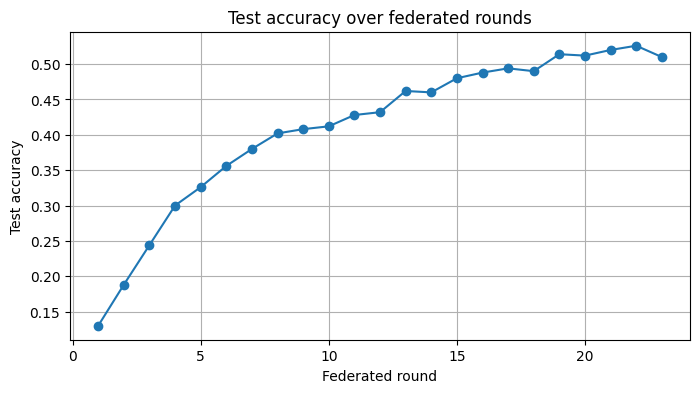

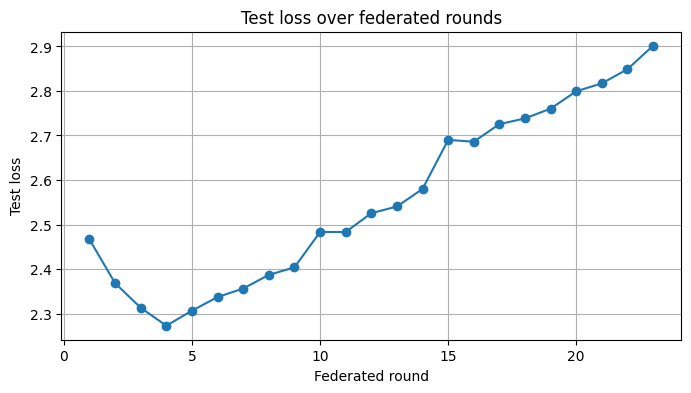

Final test loss: 2.901521535873413
Final test accuracy: 0.51


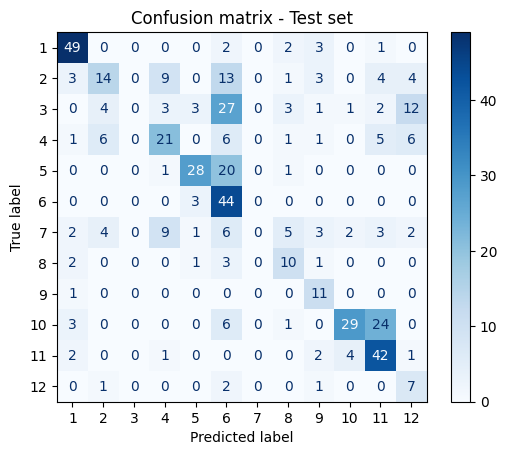

              precision    recall  f1-score   support

           1       0.78      0.86      0.82        57
           2       0.48      0.27      0.35        51
           3       0.00      0.00      0.00        56
           4       0.48      0.45      0.46        47
           5       0.78      0.56      0.65        50
           6       0.34      0.94      0.50        47
           7       0.00      0.00      0.00        37
           8       0.42      0.59      0.49        17
           9       0.42      0.92      0.58        12
          10       0.81      0.46      0.59        63
          11       0.52      0.81      0.63        52
          12       0.22      0.64      0.33        11

    accuracy                           0.51       500
   macro avg       0.44      0.54      0.45       500
weighted avg       0.48      0.51      0.46       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
#load into a tensor for PyTorch
X_test_tensor = torch.tensor(X_test_scaled.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_processed.to_numpy(), dtype=torch.long)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False)

#hiperparameters
num_rounds = 23
local_epochs = 3
batch_size = 32
learning_rate = 0.001
num_clients = 10

#initialize the global model
global_model = PoseClassifier(input_size=270, num_classes=12)
global_model = global_model.to(device)

#arrays to store the values
test_losses = []
test_accuracies = []

#iterate through all the rounds
for i in range(num_rounds):
  print(f"Round {i+1}")

  #we make the FL round
  global_model = federated_learning_round(
      global_model=global_model,
      client_loaders=client_loaders,
      client_data=client_data,
      num_clients=num_clients,
      client_fraction=1.0,
      local_epochs=local_epochs,
      lr=learning_rate,
      device=device
  )

  #evaluate the model
  test_loss, test_accuracy = evaluate_model(
      model=global_model,
      data_loader=test_loader,
      device=device
  )

  test_losses.append(test_loss)
  test_accuracies.append(test_accuracy)

  print(f"Test loss: {test_loss}")
  print(f"Test accuracy: {test_accuracy}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_rounds + 1), test_accuracies, marker="o")
plt.xlabel("Federated round")
plt.ylabel("Test accuracy")
plt.title("Test accuracy over federated rounds")
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(range(1, num_rounds + 1), test_losses, marker="o")
plt.xlabel("Federated round")
plt.ylabel("Test loss")
plt.title("Test loss over federated rounds")
plt.grid(True)
plt.show()


final_test_loss, final_test_accuracy = evaluate_model(
    model=global_model,
    data_loader=test_loader,
    device=device
)

print(f"Final test loss: {final_test_loss}")
print(f"Final test accuracy: {final_test_accuracy}")

all_predictions = []
all_labels = []

global_model.eval()

with torch.no_grad():
  for X_batch, y_batch in test_loader:
    X_batch = X_batch.to(device)
    outputs = global_model(X_batch)
    predictions = torch.argmax(outputs, dim=1)

    all_predictions.extend(predictions.cpu().numpy())
    all_labels.extend(y_batch.cpu().numpy())

all_predictions_original = [p+1 for p in all_predictions]
all_labels_original = [y+1 for y in all_labels]

cm = confusion_matrix(all_labels_original, all_predictions_original)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(1, 13))
)

disp.plot(cmap="Blues", xticks_rotation=0)
plt.title("Confusion matrix - Test set")
plt.show()

print(classification_report(all_labels_original, all_predictions_original, labels=list(range(1, 13))))

This is the final block where we finally train and evaluate the FL model. We define the hiperparameters selected in the previous evaluation (a similar ones) and train the global model using the FL and finally evaluating it with the tests datasets.

We can see that the final accuracy and loss of the model are

Final test loss: 2.9442616863250732
Final test accuracy: 0.544

We can see is not a much higher accuracy but the model is learing anyway. We can see in the plot of the test acuracy that the model learns a lot in the firsts rounds and then is more stable. This means that the trainning converges.

The plot of the loss we can see that first it decreases and then it increases. This could mean that the model is overfitting.

The confusion matrix shows us that some clases classifies well, like 1,4,5,6,10 and 11. However, there are other that they are problematic like 3 or 7. This means that the model has some problems to recognize some poses.

Finally, the clasification report confirms the accuracy and that the performance is not uniform between clases. Some classes have a good F1 score like the 1 with 0.78 but other have lower values.